In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

In [2]:
#Load dataset
Dibetes_df = pd.read_csv('diabetes_dataset.csv')

In [3]:
### Data Simple info
Dibetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

### EDA Step 1 : Data Cleaning 

#### Check Missing Values

In [4]:
## looking For Null values in Data Frame
Dibetes_df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


There are no null values in the data frame

In [5]:
# Describe the dataset
Dibetes_df.describe().round(2)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50.12,2.00,118.91,5.99,7.00,6.00,0.22,0.25,0.08,25.61,...,185.98,54.04,103.00,121.46,111.12,160.04,9.06,6.52,30.22,0.60
std,15.60,1.42,84.41,1.78,1.09,2.47,0.41,0.43,0.27,3.59,...,32.01,10.27,33.39,43.37,13.60,30.94,4.95,0.81,9.06,0.49
min,18.00,0.00,0.00,0.00,3.00,0.50,0.00,0.00,0.00,15.00,...,100.00,20.00,50.00,30.00,60.00,70.00,2.00,4.00,2.70,0.00
25%,39.00,1.00,57.00,4.80,6.30,4.30,0.00,0.00,0.00,23.20,...,164.00,47.00,78.00,91.00,102.00,139.00,5.09,5.97,23.80,0.00
50%,50.00,2.00,100.00,6.00,7.00,6.00,0.00,0.00,0.00,25.60,...,186.00,54.00,102.00,121.00,111.00,160.00,8.79,6.52,29.00,1.00
75%,61.00,3.00,160.00,7.20,7.70,7.70,0.00,1.00,0.00,28.00,...,208.00,61.00,126.00,151.00,120.00,181.00,12.45,7.07,35.60,1.00
max,90.00,10.00,833.00,10.00,10.00,16.80,1.00,1.00,1.00,39.20,...,318.00,98.00,263.00,344.00,172.00,287.00,32.22,9.80,67.20,1.00


The dataset seems balanced and clean (no missing values).
Population is middle-aged, slightly overweight, and moderately active.
Pre-diabetes and diabetes are common — elevated glucose and HbA1c levels support this.
Lifestyle risk factors: high screen time, moderate diet and physical activity.
Risk model seems to align with actual diagnosis — high mean HbA1c and fasting glucose match 60% diagnosed diabetes rate.

### EDA Step 2:Data Set Column Explanation

#### Numarical Columns

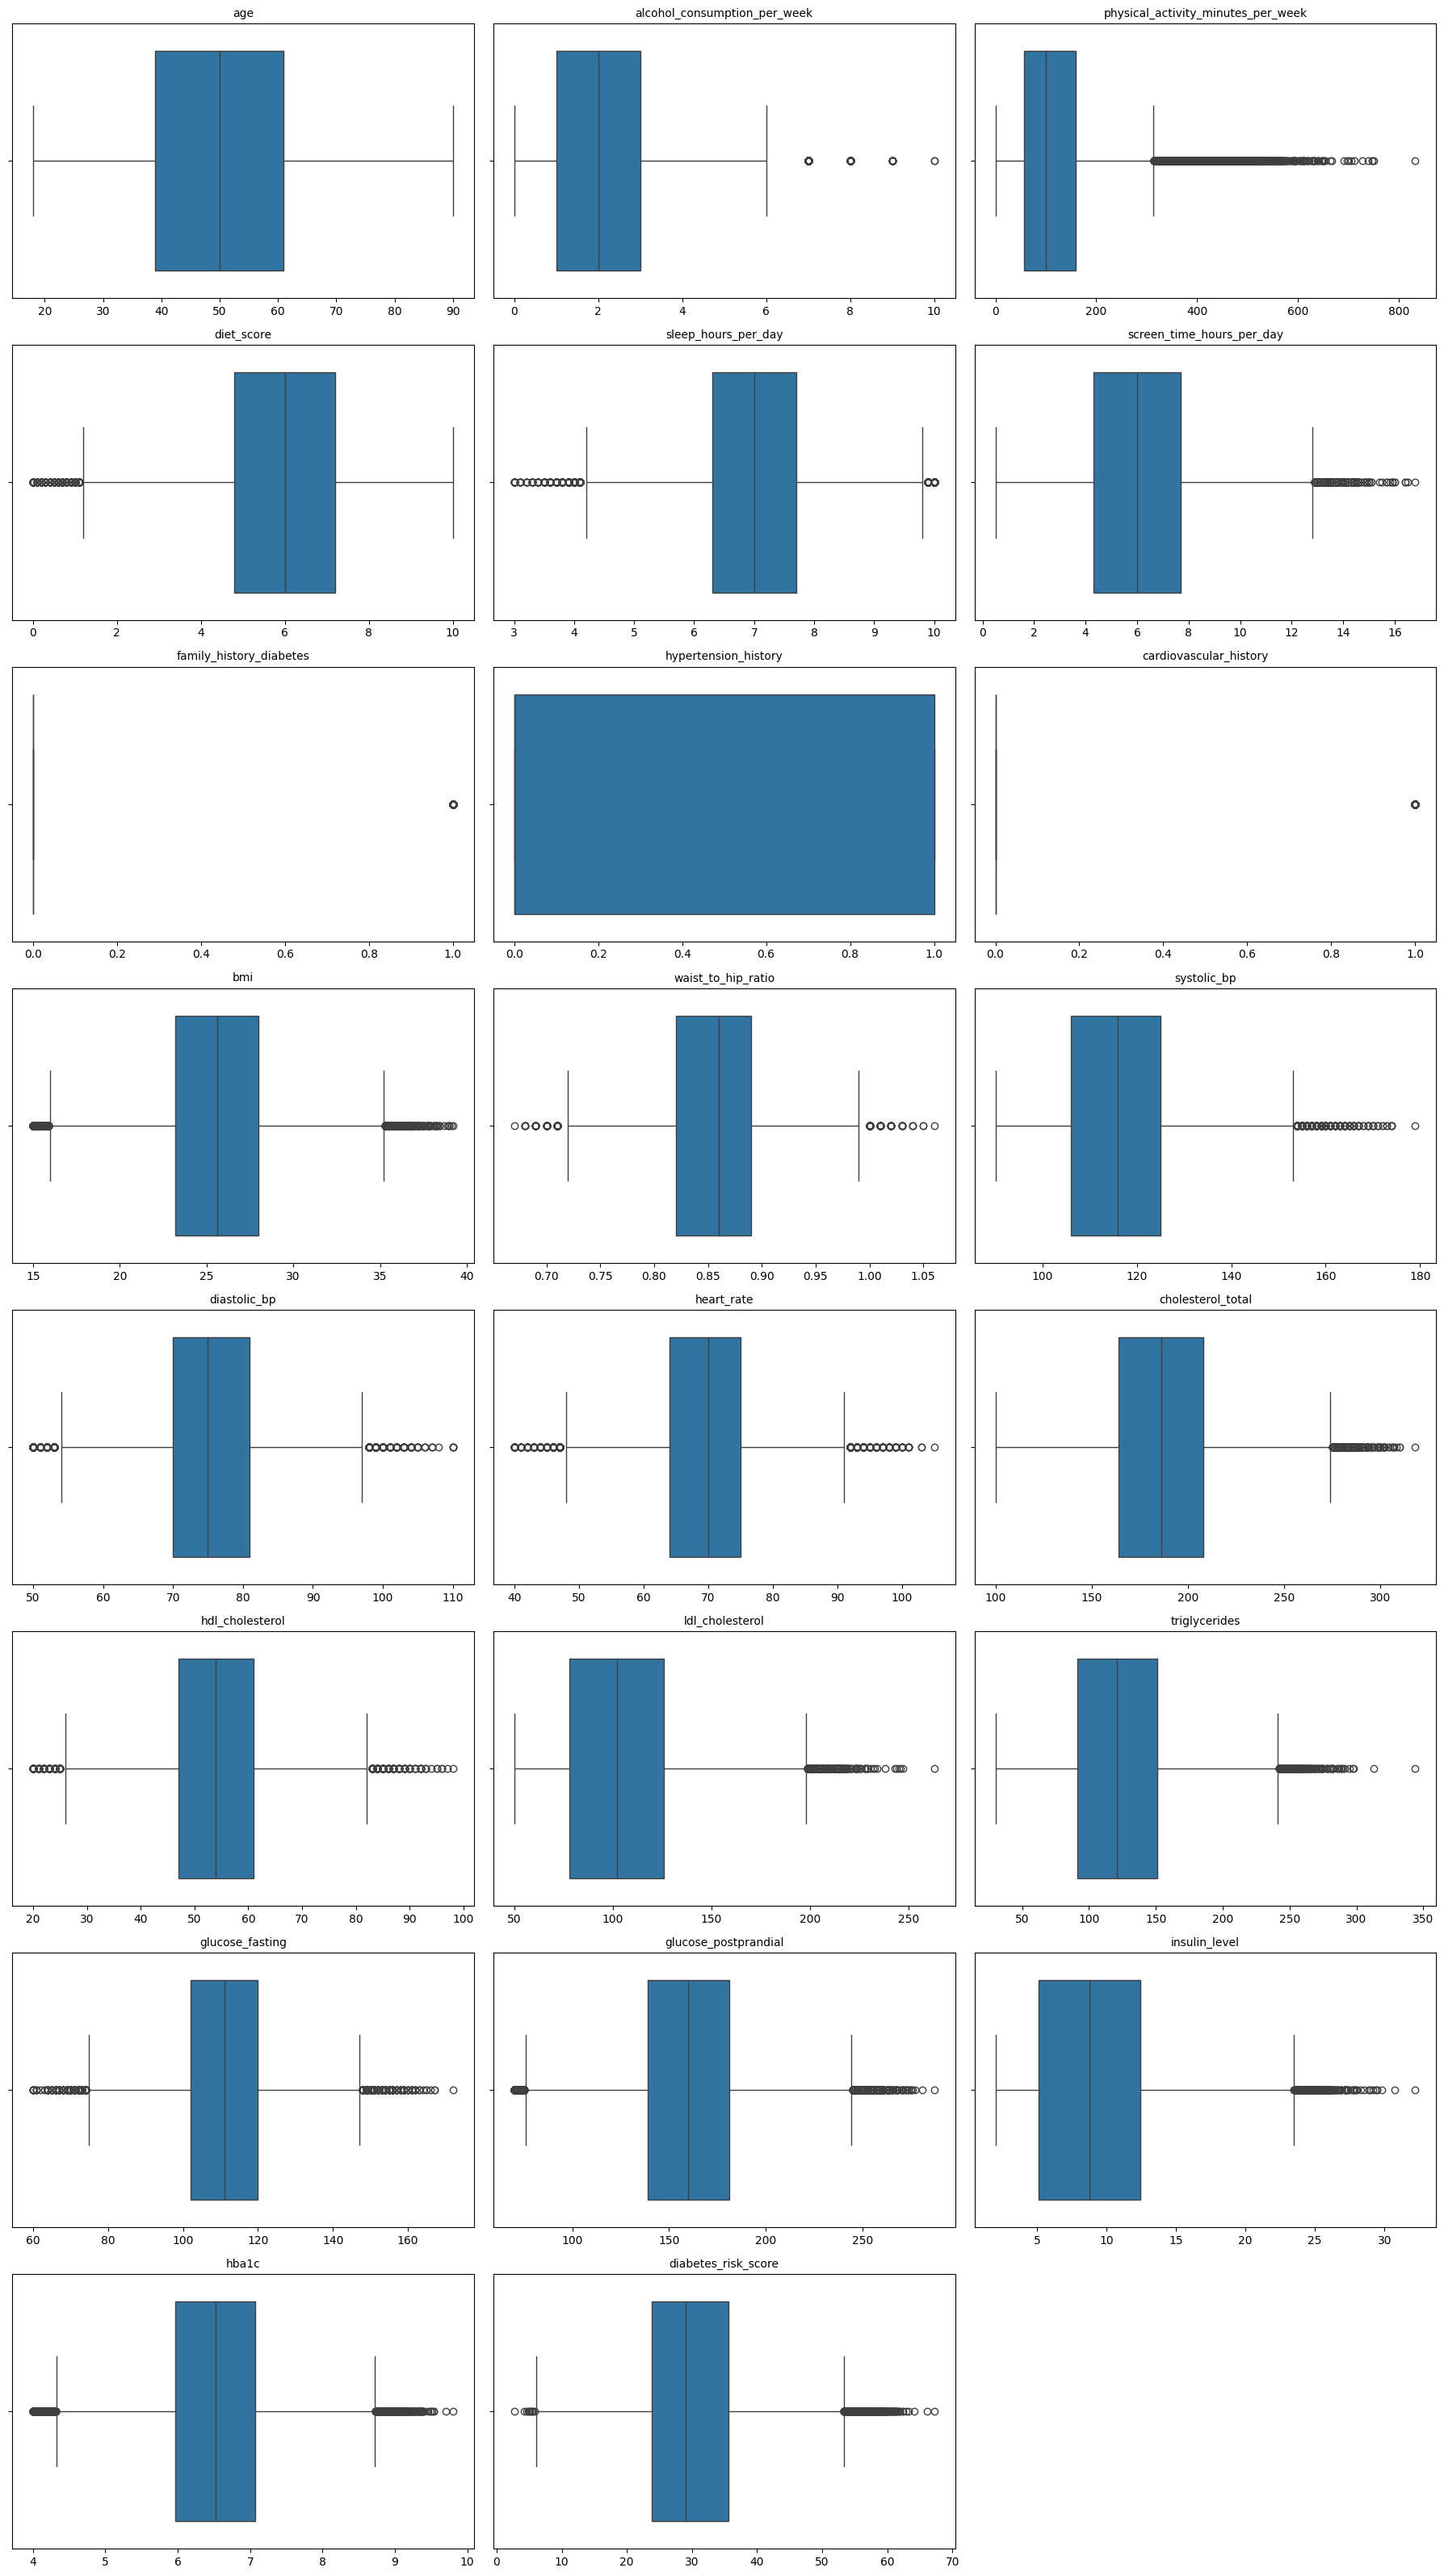

In [6]:
## Detect Outliers using Boxplot in Numeric Columns
# Select numeric columns excluding 'diagnosed_diabetes'
numeric_cols = [col for col in Dibetes_df.select_dtypes(include=np.number).columns if col != 'diagnosed_diabetes']

# Define layout: 3 boxplots per row
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, column in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=Dibetes_df[column])
    plt.title(f'{column}', fontsize=10)
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

Some variables (like alcohol, physical activity, glucose, triglycerides) have many high outliers, meaning a few people have extremely high values.Medical historycolumns don’t have outliers.
Most people fall in normal healthy ranges, but outliers indicate potential health risks or exceptional behaviors.

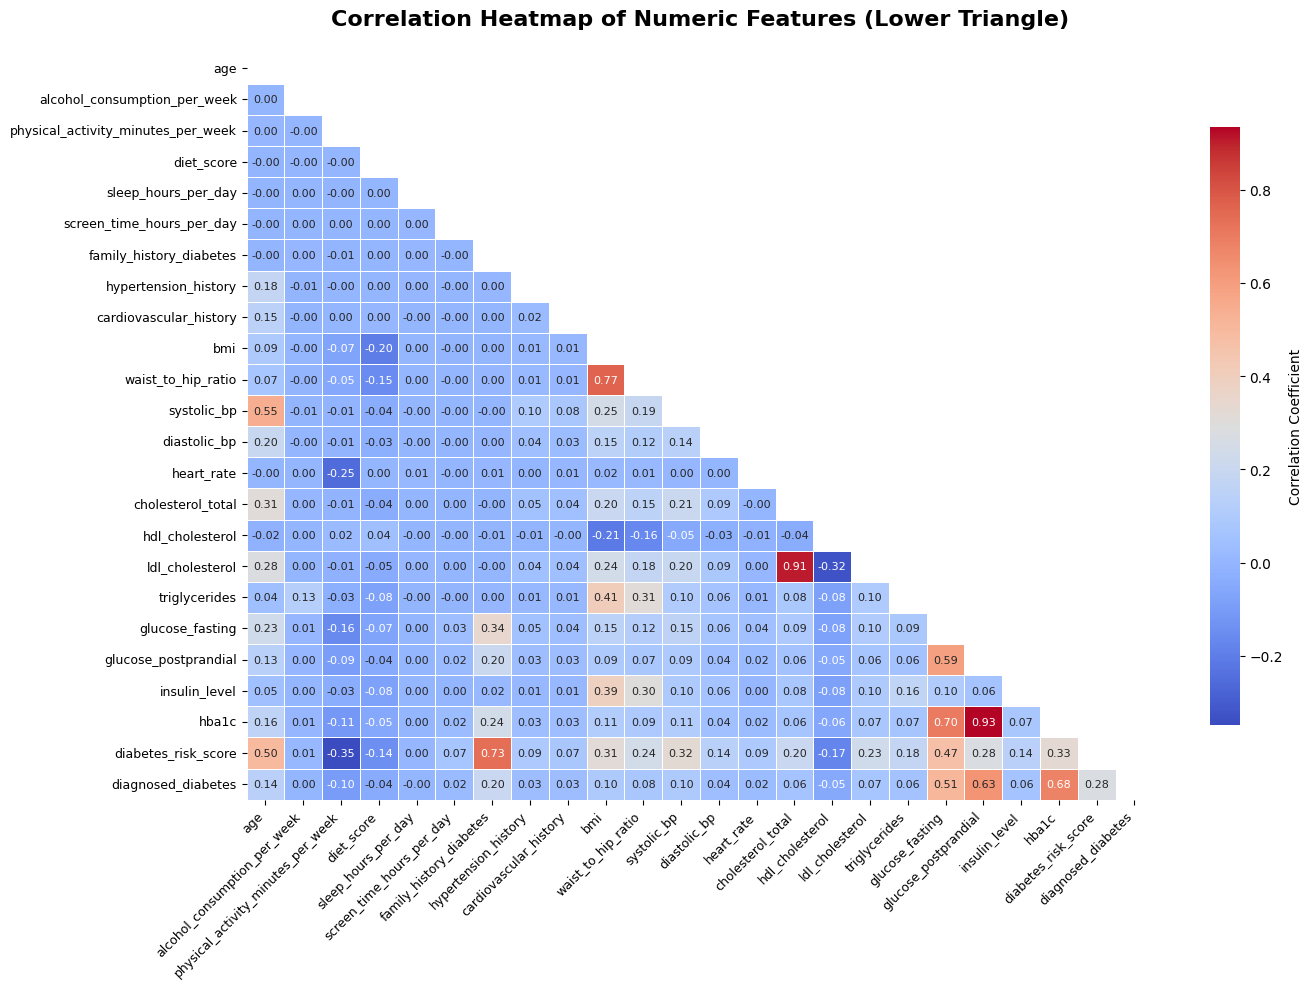

In [7]:
## Heatmap to show correlation between Numeric Columns
# Compute correlation matrix
# Select only numeric columns
numeric_df = Dibetes_df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# Mask the upper triangle (including diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up figure
plt.figure(figsize=(14, 10))

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 8}
)

# Improve readability
plt.title("Correlation Heatmap of Numeric Features (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.show()

##### Strongest clusters:
    Cholesterol-related features (ex:LDL, HDL, Total)
    Glucose-related features (ex:Glucose, HbA1c, Insulin, Risk score, Diabetes status)
    Body measures (ex:BMI, Waist-to-hip ratio)
##### Lifestyle variables (ex:alcohol, sleep, activity)
    show low direct correlations, suggesting their effects might be indirect or combined with other factors.
##### Medical indicators (ex: glucose and HbA1c)
    have the clearest relationships with diabetes risk and diagnosis

### Catagorical Column Analyasis 

/tmp/ipykernel_34977/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_34977/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_34977/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_34977/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_34977/317

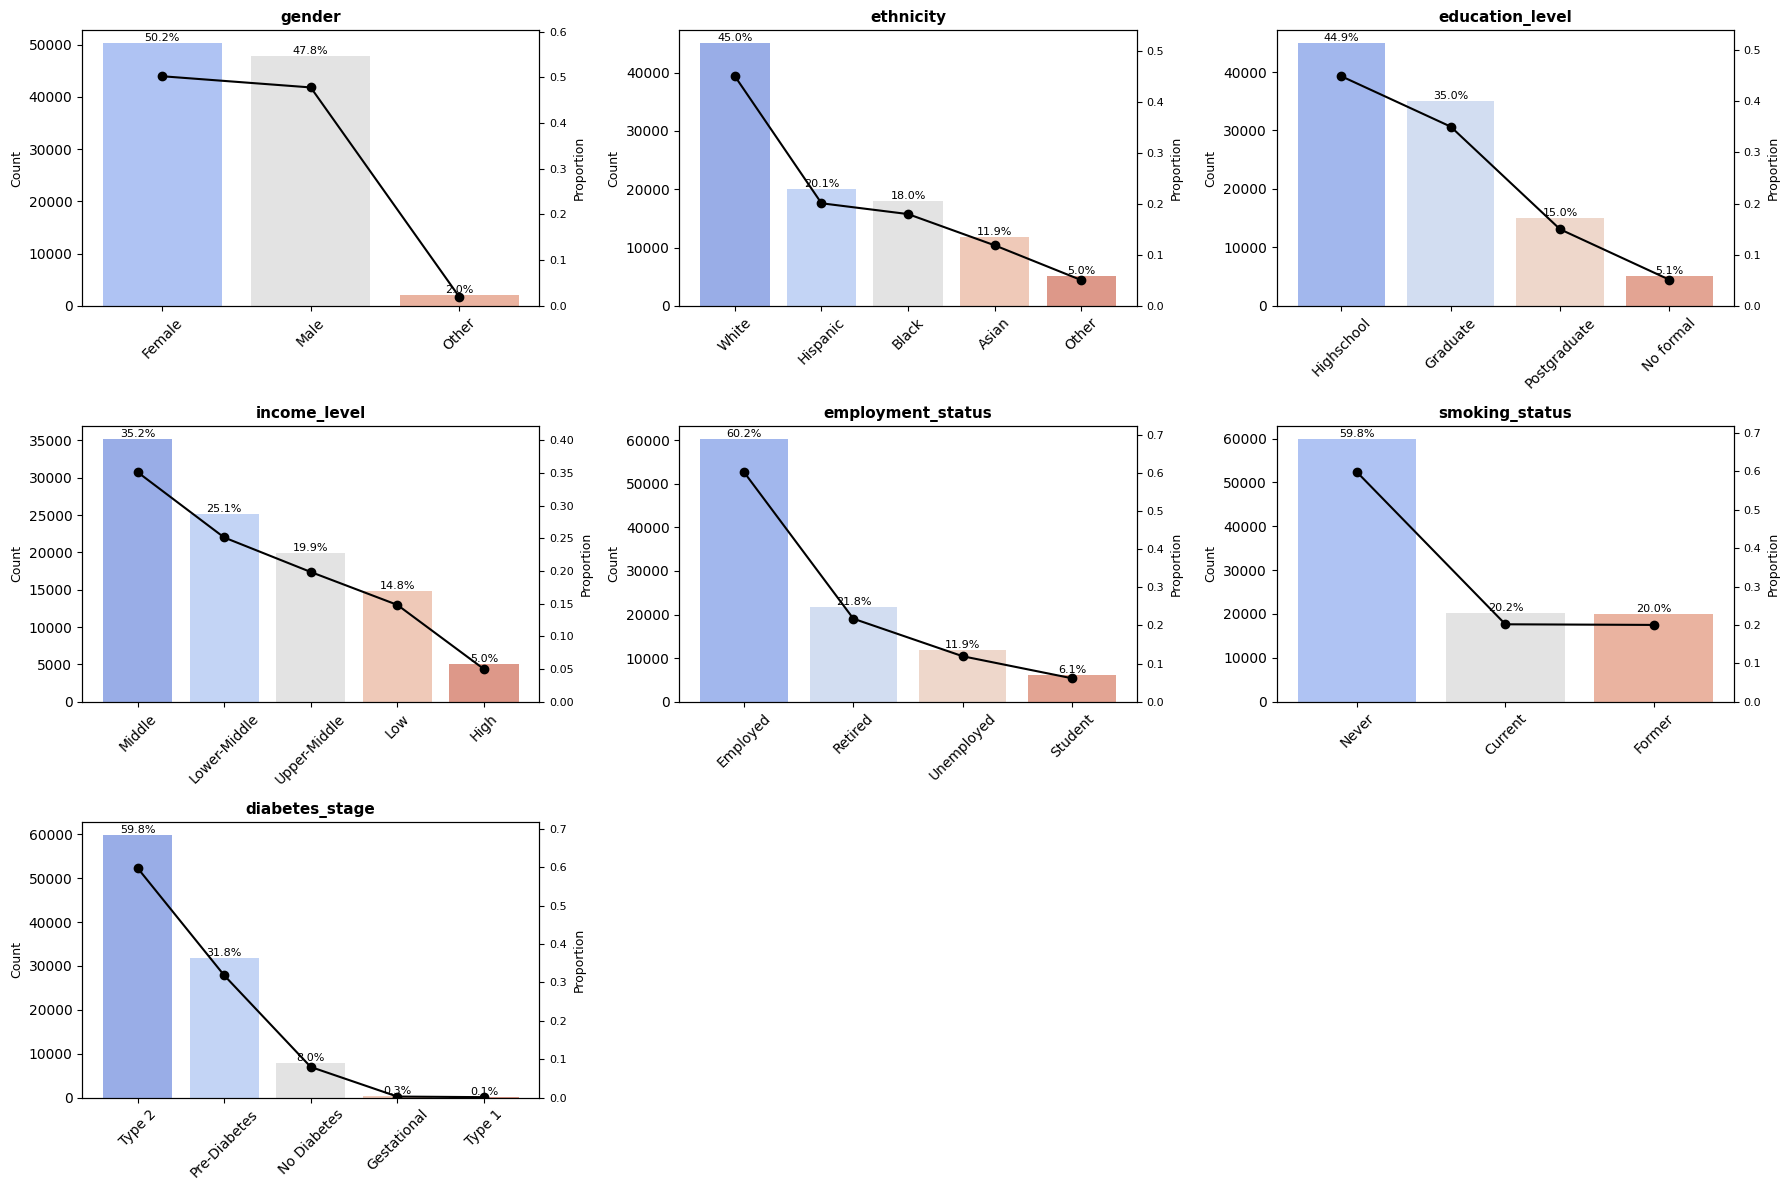

In [8]:
categorical_cols = Dibetes_df.select_dtypes(include='object').columns
# Number of rows & columns for layout
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, column in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Create the count plot
    ax = sns.countplot(
        x=Dibetes_df[column],
        order=Dibetes_df[column].value_counts().index,
        palette="coolwarm",
        alpha=0.8
    )

    # Add line for distribution trend
    counts = Dibetes_df[column].value_counts().values
    x_positions = np.arange(len(counts))
    ax2 = ax.twinx()
    ax2.plot(x_positions, counts / counts.sum(), color='black', marker='o', linewidth=1.5, label='Distribution')
    ax2.set_ylim(0, max(counts / counts.sum()) * 1.2)
    ax2.set_ylabel('Proportion', fontsize=9, color='black')
    ax2.tick_params(axis='y', labelsize=8)
    
    # Annotate percentage on bars
    total = len(Dibetes_df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height/total:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, color='black')

    # Titles and formatting
    ax.set_title(f'{column}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.legend([],[], frameon=False)
    
plt.tight_layout()
plt.show()


dataset has a mostly working-age, middle-income population.
Most people are employed, non-smokers, and have Type 2 diabetes or pre-diabetes, with balanced gender distribution and mainly White ethnicity.

## Get Analyasis Catagorical & Numarical Column Correlations against Target Variable [diagnosed_diabetes]

/tmp/ipykernel_2661/1789548787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


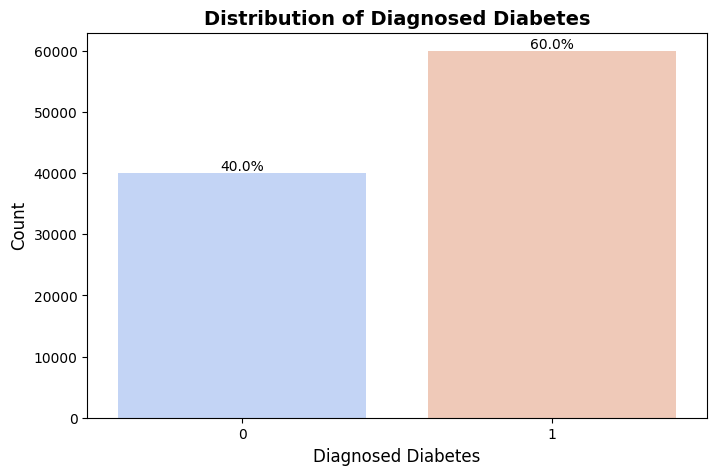

In [9]:
# Target Variable Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x=Dibetes_df['diagnosed_diabetes'],
    palette="coolwarm",
    alpha=0.8
)
# Add percentage annotations
total = len(Dibetes_df['diagnosed_diabetes'])
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height/total:.1%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')
ax.set_title('Distribution of Diagnosed Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosed Diabetes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.show()

Between the results of 'Diagnosed Diabetes' target variable of 1[Is Diabtes] & 0[No Diabtes] we have distribution of 60% and 40% and this is a balnced data set that we can use for ML model building.

### Catagorical Columns Analysis vs Target

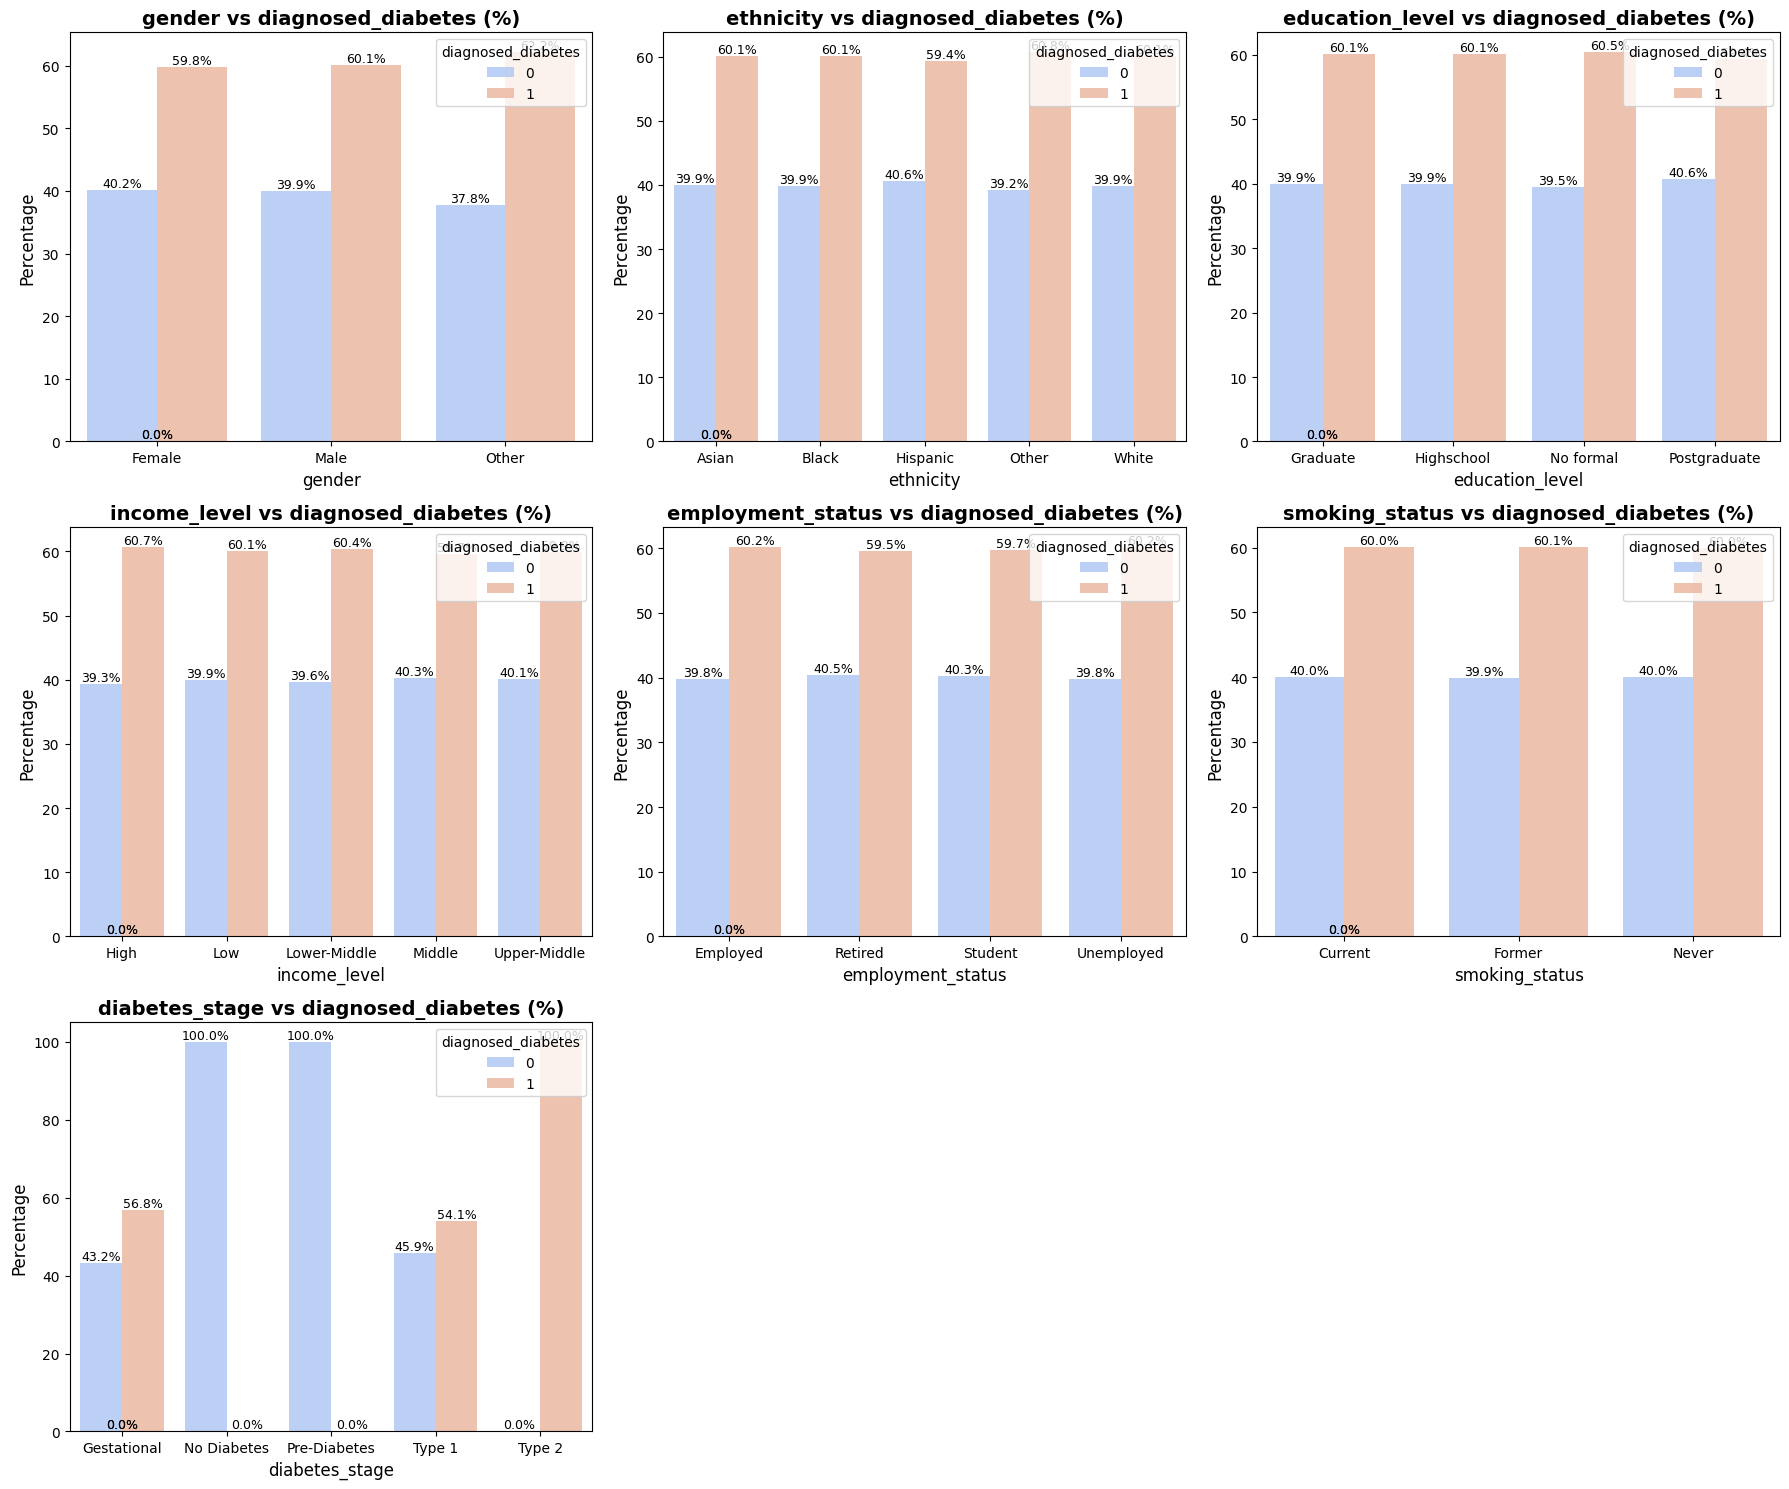

In [18]:
# Define target variable
target = 'diagnosed_diabetes'

# Automatically detect categorical variables except the target
categorical_cols = [
    col for col in Dibetes_df.select_dtypes(include=['object', 'category']).columns
    if col != target
]

# Create subplots
n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Compute percentages safely (avoiding column name issues)
    temp = Dibetes_df.groupby([col, target]).size().unstack(fill_value=0)
    temp = temp.apply(lambda x: 100 * x / x.sum(), axis=1).reset_index()
    
    # Melt to long format for seaborn
    temp_df = temp.melt(id_vars=col, var_name=target, value_name='Percentage')
    
    # Plot
    sns.barplot(
        data=temp_df,
        x=col,
        y='Percentage',
        hue=target,
        palette='coolwarm',
        ax=axes[i],
        alpha=0.9
    )

    # Annotate bars
    for p in axes[i].patches:
        height = p.get_height()
        if not pd.isna(height):
            axes[i].annotate(f'{height:.1f}%',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom',
                             fontsize=9, color='black')

    axes[i].set_title(f'{col} vs {target} (%)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Percentage', fontsize=12)
    axes[i].legend(title=target, loc='upper right')

# Remove any extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The distribution of diabetes diagnosis is fairly similar across most demographic groups (gender, ethnicity, income, education, etc.).

The only clear separation is in the diabetes_stage feature — as expected, since it directly indicates diabetes status.[since there is strong correlation against Target may indicate overfitting so we can most possibly drop this ferture]

There’s no major imbalance or strong predictor visible just from these categorical comparisons — meaning diabetes may depend more on continuous factors (like glucose, BMI, or age) rather than these categorical demographics alone.

Chi-square test for gender vs diagnosed_diabetes:
Chi2 Statistic: 4.6292067375610335, p-value: 0.09880536552392973

No significant association between gender and diagnosed_diabetes (p >= 0.05)

Chi-square test for ethnicity vs diagnosed_diabetes:
Chi2 Statistic: 4.684895617166723, p-value: 0.32118294592539454

No significant association between ethnicity and diagnosed_diabetes (p >= 0.05)

Chi-square test for education_level vs diagnosed_diabetes:
Chi2 Statistic: 3.354838256579342, p-value: 0.3400828191688993

No significant association between education_level and diagnosed_diabetes (p >= 0.05)

Chi-square test for income_level vs diagnosed_diabetes:
Chi2 Statistic: 4.393047063592937, p-value: 0.3554183584482451

No significant association between income_level and diagnosed_diabetes (p >= 0.05)

Chi-square test for employment_status vs diagnosed_diabetes:
Chi2 Statistic: 3.0155838272502806, p-value: 0.38922869181679415

No significant association between employment_status and diagnosed

/tmp/ipykernel_2661/2766251582.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


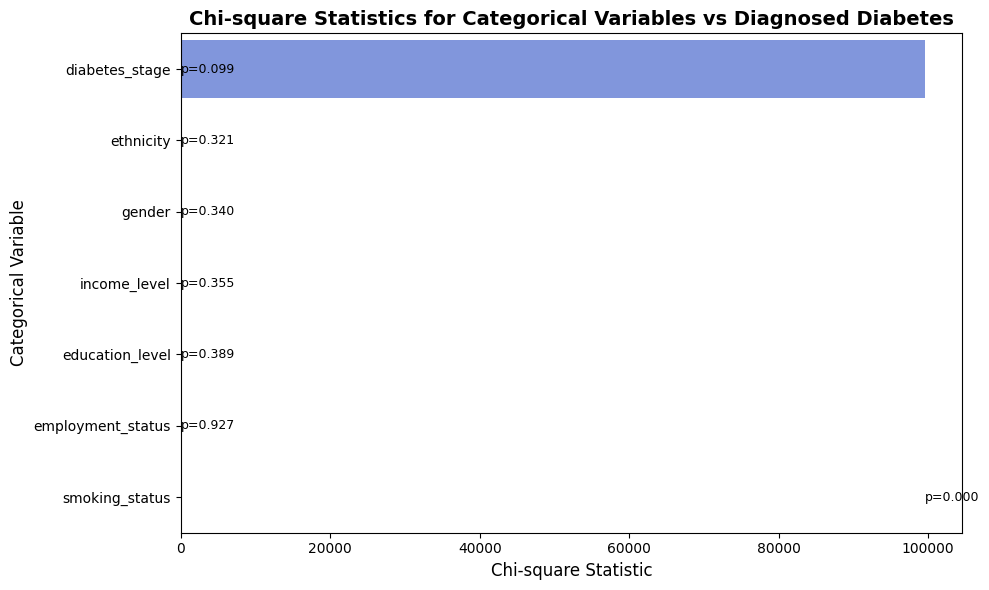

In [23]:
from scipy.stats import norm, chi2_contingency

# Store results
chi2_results = []

# Catagorical Columns correlation with Target Variable
categorical_cols = Dibetes_df.select_dtypes(include='object').columns
for column in categorical_cols:
    contingency_table = pd.crosstab(Dibetes_df[column], Dibetes_df['diagnosed_diabetes'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Variable': column, 'Chi2': chi2, 'p-value': p})
    print(f'Chi-square test for {column} vs diagnosed_diabetes:')
    print(f'Chi2 Statistic: {chi2}, p-value: {p}\n')
    if p < 0.05:
        print(f'There is a significant association between {column} and diagnosed_diabetes (p < 0.05)\n')
    else:
        print(f'No significant association between {column} and diagnosed_diabetes (p >= 0.05)\n')
# Convert results to DataFrame
chi2_df = pd.DataFrame(chi2_results).sort_values(by='Chi2', ascending=False)

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=chi2_df,
    x='Chi2',
    y='Variable',
    palette='coolwarm',
    alpha=0.9
)

# Highlight significance visually
for i, row in chi2_df.iterrows():
    label = f"p={row['p-value']:.3f}"
    plt.text(row['Chi2'] + 0.02, i, label, va='center', fontsize=9)

plt.title('Chi-square Statistics for Categorical Variables vs Diagnosed Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Chi-square Statistic', fontsize=12)
plt.ylabel('Categorical Variable', fontsize=12)
plt.tight_layout()
plt.show()

        
        

The only categorical variable that shows a strong link with diagnosed diabetes is diabetes_stage.
All other variables (like gender, income, ethnicity, etc.) do not show a statistically significant relationship with whether a person has been diagnosed with diabetes.

### Numarical Column Correlation With Target

Strong correlation between age and diagnosed_diabetes: 0.1377
Weak correlation between alcohol_consumption_per_week and diagnosed_diabetes: 0.0008
Strong correlation between physical_activity_minutes_per_week and diagnosed_diabetes: -0.1008
Weak correlation between diet_score and diagnosed_diabetes: -0.0443
Weak correlation between sleep_hours_per_day and diagnosed_diabetes: -0.0004
Weak correlation between screen_time_hours_per_day and diagnosed_diabetes: 0.0181
Strong correlation between family_history_diabetes and diagnosed_diabetes: 0.1979
Weak correlation between hypertension_history and diagnosed_diabetes: 0.0275
Weak correlation between cardiovascular_history and diagnosed_diabetes: 0.0298
Strong correlation between bmi and diagnosed_diabetes: 0.0971
Strong correlation between waist_to_hip_ratio and diagnosed_diabetes: 0.0789
Strong correlation between systolic_bp and diagnosed_diabetes: 0.0955
Weak correlation between diastolic_bp and diagnosed_diabetes: 0.0356
Weak correlation

/tmp/ipykernel_2661/2436554961.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


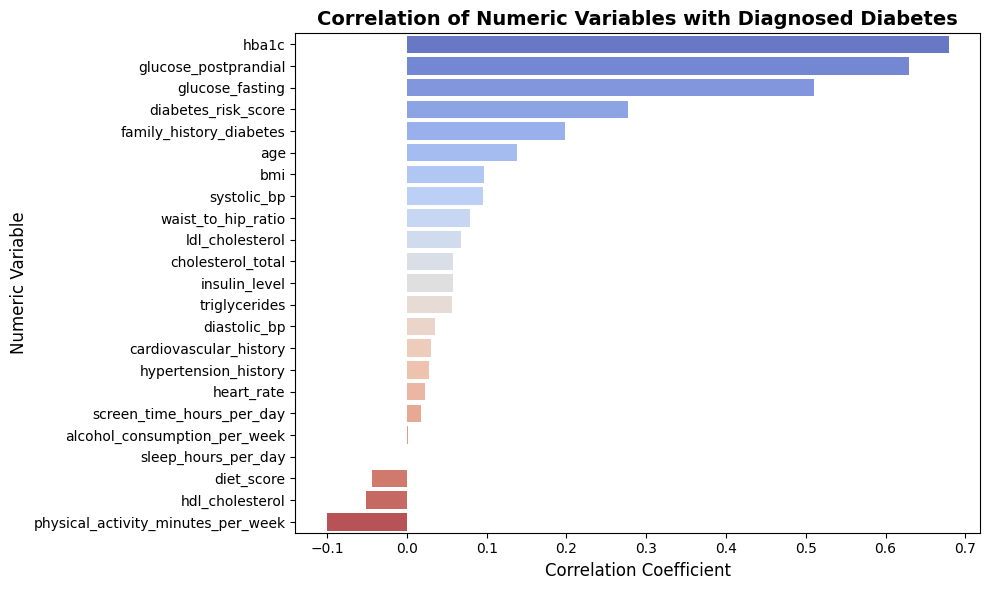

In [29]:
# numarical Columns correlation with Target Variable Simple correlation
numeric_cols = Dibetes_df.select_dtypes(include=np.number).columns.drop('diagnosed_diabetes')
correlations = {}
for col in numeric_cols:
    corr = Dibetes_df[col].corr(Dibetes_df['diagnosed_diabetes'])
    correlations[col] = corr
    if abs(corr) > 0.05: # Threshold for notable correlation
        print(f'Strong correlation between {col} and diagnosed_diabetes: {corr:.4f}')
    else:
        print(f'Weak correlation between {col} and diagnosed_diabetes: {corr:.4f}')
# Convert to DataFrame for better visualization
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation']).sort_values(by='Correlation', ascending=False)
# Plot correlations
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_df.reset_index(),
    x='Correlation',
    y='index',
    palette='coolwarm',
    alpha=0.9
)
plt.title('Correlation of Numeric Variables with Diagnosed Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Numeric Variable', fontsize=12)
plt.tight_layout()
plt.show()
    


People with higher blood sugar levels, older age, higher BMI, and family history of diabetes are more likely to be diagnosed with diabetes.
Meanwhile, those who exercise more and have higher HDL cholesterol tend to have a lower risk of diabetes.

## One Hot Encode the Catagorical Variables and Analyasis

In [30]:
# One Hot Encode the Catagorical Variables
Dibetes_df_encoded = pd.get_dummies(Dibetes_df, drop_first=True)
Dibetes_df_encoded.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,income_level_Upper-Middle,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Former,smoking_status_Never,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,False,False,False,False,False,True,False,False,False,True
1,48,1,143,6.7,6.5,8.7,0,0,0,23.1,...,False,False,False,False,True,False,True,False,False,False
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,False,False,False,True,False,True,False,False,False,True
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,False,True,False,False,False,True,False,False,False,True
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,False,True,False,False,False,True,False,False,False,True


In [31]:
# One Hot Encode DF Info
Dibetes_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                

<Axes: >

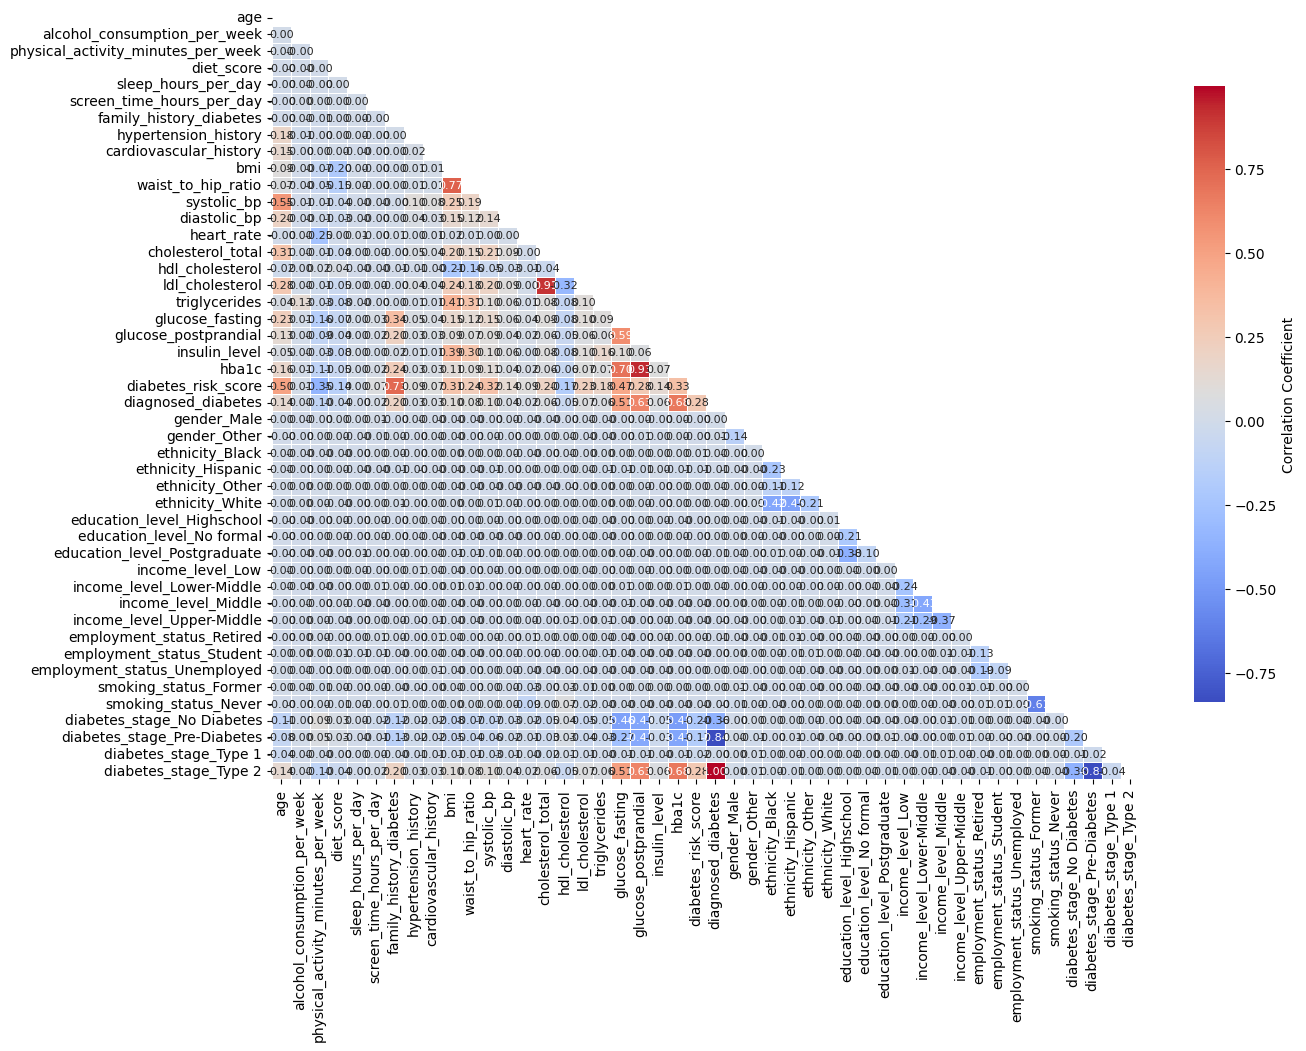

In [33]:
# one hot encode all ferture correlation
corr_encoded = Dibetes_df_encoded.corr()
# Sort correlation and heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_encoded,
    mask=np.triu(np.ones_like(corr_encoded, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 8}
)



Blood sugar measures (HbA1c, glucose fasting, glucose postprandial) are tightly linked.
Blood pressure measures are tightly linked.
Body fat indicators (BMI, waist-to-hip ratio) move together.
HDL cholesterol behaves oppositely to triglycerides.
Lifestyle or demographic factors (like income, education, or gender) show much weaker direct correlations with these health outcomes.

/tmp/ipykernel_2661/3345704025.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


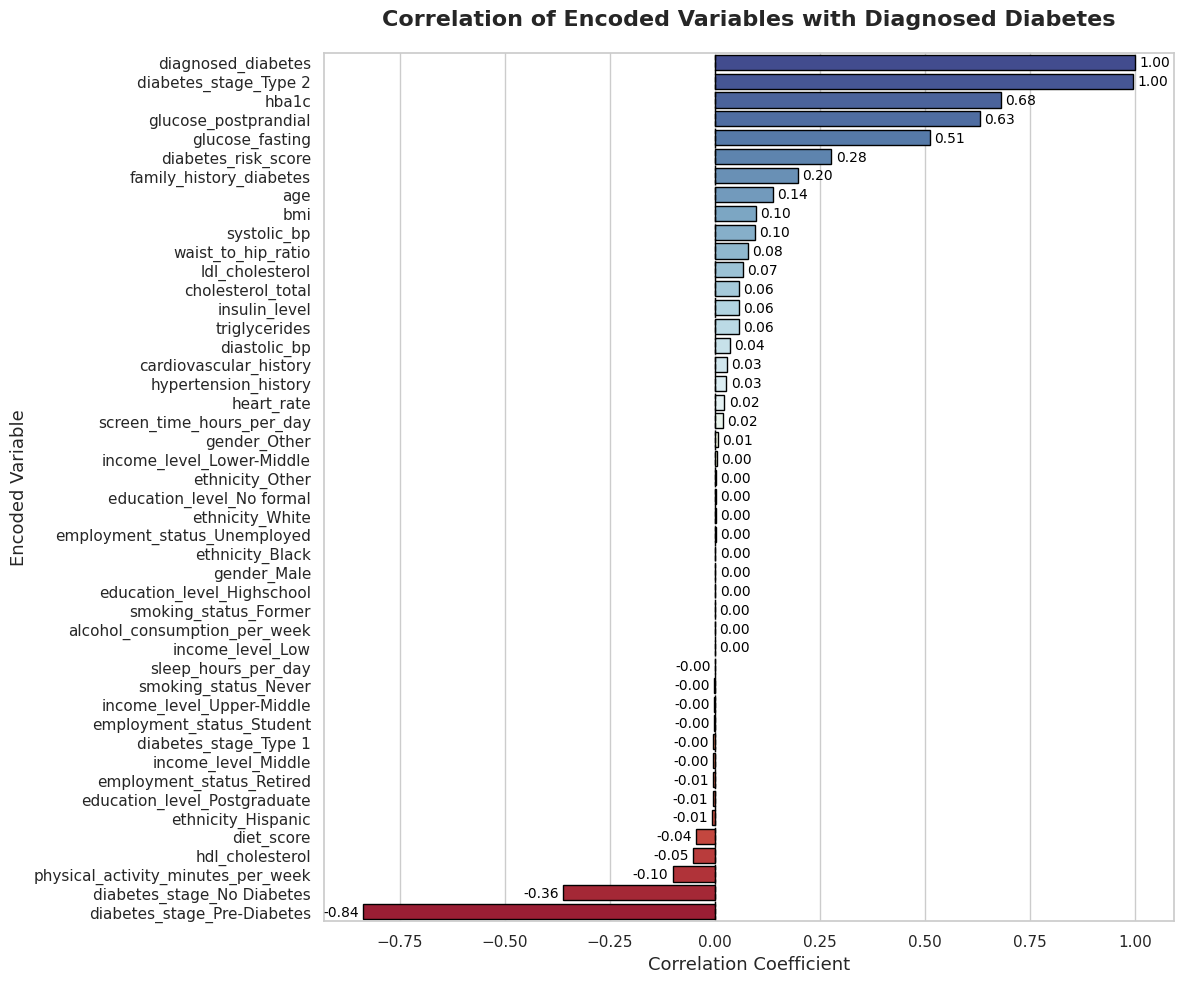

In [37]:
## one hot encode all ferture correlation  to Target
# Sort correlations with diagnosed_diabetes
# Target variable
target = 'diagnosed_diabetes'
corr_target = corr_encoded[[target]].sort_values(by=target, ascending=False)

# Set style
sns.set_theme(style="whitegrid")

# Create horizontal bar plot
plt.figure(figsize=(12, 10))
sns.barplot(
    data=corr_target.reset_index(),
    y='index',
    x=target,
    palette='RdYlBu_r',   # Red–blue gradient
    edgecolor='black'
)

# Title and labels
plt.title(
    'Correlation of Encoded Variables with Diagnosed Diabetes',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.ylabel('Encoded Variable', fontsize=13)
plt.xlabel('Correlation Coefficient', fontsize=13)

# Vertical line at 0 for reference
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Add correlation value labels to bars
for i, (value, name) in enumerate(zip(corr_target[target], corr_target.index)):
    plt.text(
        value + (0.01 if value > 0 else -0.01),  # offset text to the right or left
        i,
        f'{value:.2f}',
        color='black',
        va='center',
        ha='left' if value > 0 else 'right',
        fontsize=10
    )

# Improve spacing and appearance
plt.tight_layout()
plt.show()


#### Get The Correlation with Target Columns by excluding obvious fertures 

/tmp/ipykernel_2661/1482499365.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


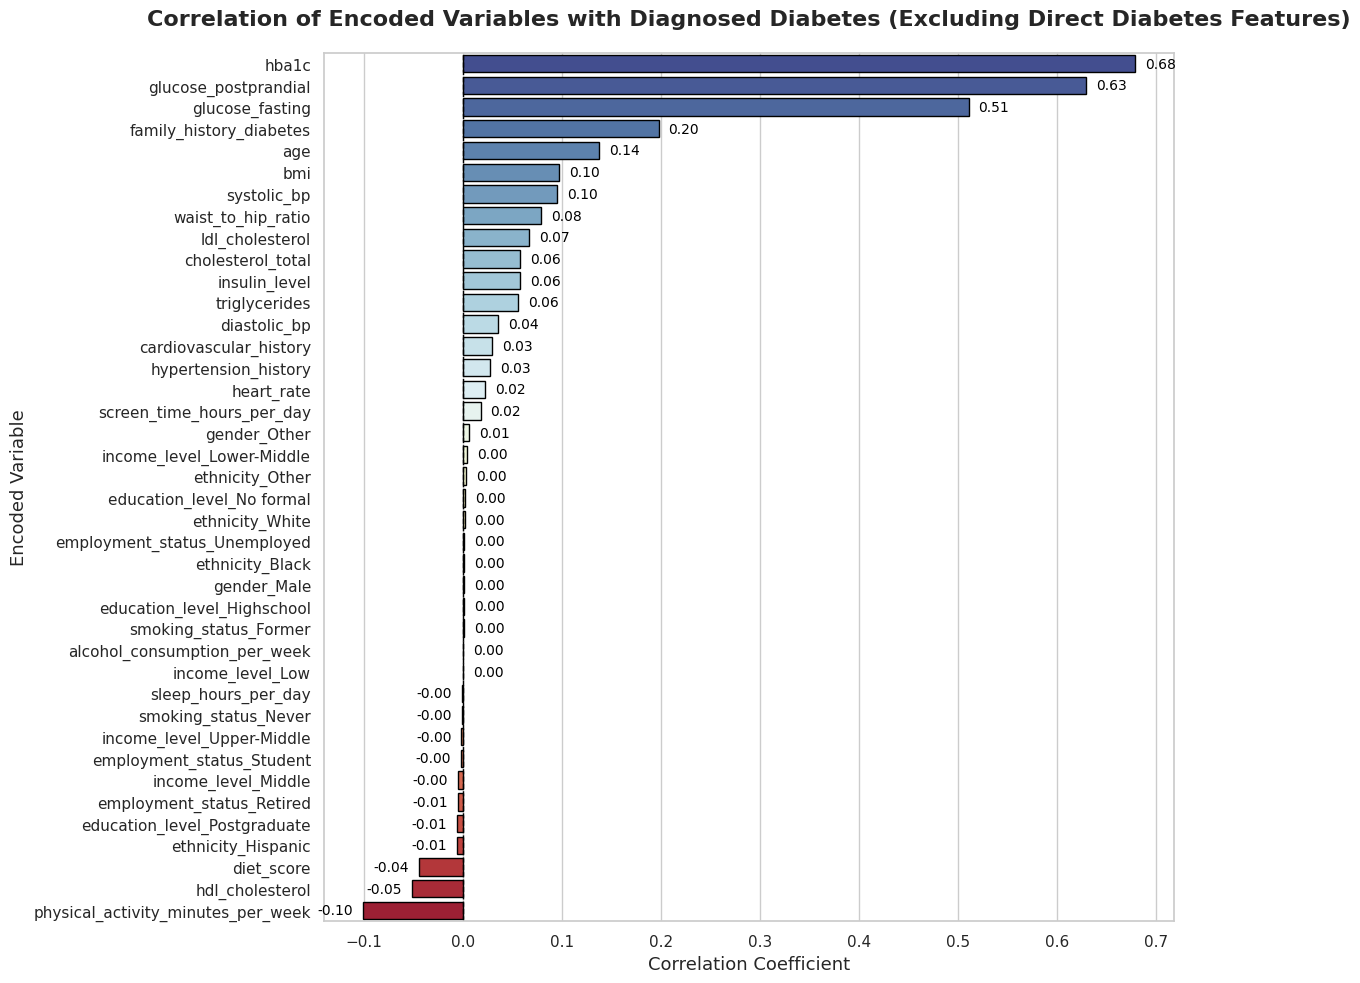

In [38]:
# Define target and features to exclude (directly related to diabetes)
target = 'diagnosed_diabetes'
exclude_features = [
    'diagnosed_diabetes',
    'diabetes_stage_Type 1',
    'diabetes_stage_Type 2',
    'diabetes_stage_Pre-Diabetes',
    'diabetes_stage_No Diabetes',
    'diabetes_risk_score'
]

# Filter out excluded features
filtered_corr = corr_encoded.drop(index=exclude_features, errors='ignore')[[target]].sort_values(by=target, ascending=False)

# Plot setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Create horizontal bar plot
sns.barplot(
    data=filtered_corr.reset_index(),
    y='index',
    x=target,
    palette='RdYlBu_r',
    edgecolor='black'
)

# Title and labels
plt.title(
    'Correlation of Encoded Variables with Diagnosed Diabetes (Excluding Direct Diabetes Features)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.ylabel('Encoded Variable', fontsize=13)
plt.xlabel('Correlation Coefficient', fontsize=13)

# Reference line at zero
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Add correlation value labels
for i, (value, name) in enumerate(zip(filtered_corr[target], filtered_corr.index)):
    plt.text(
        value + (0.01 if value > 0 else -0.01),
        i,
        f'{value:.2f}',
        color='black',
        va='center',
        ha='left' if value > 0 else 'right',
        fontsize=10
    )

plt.tight_layout()
plt.show()

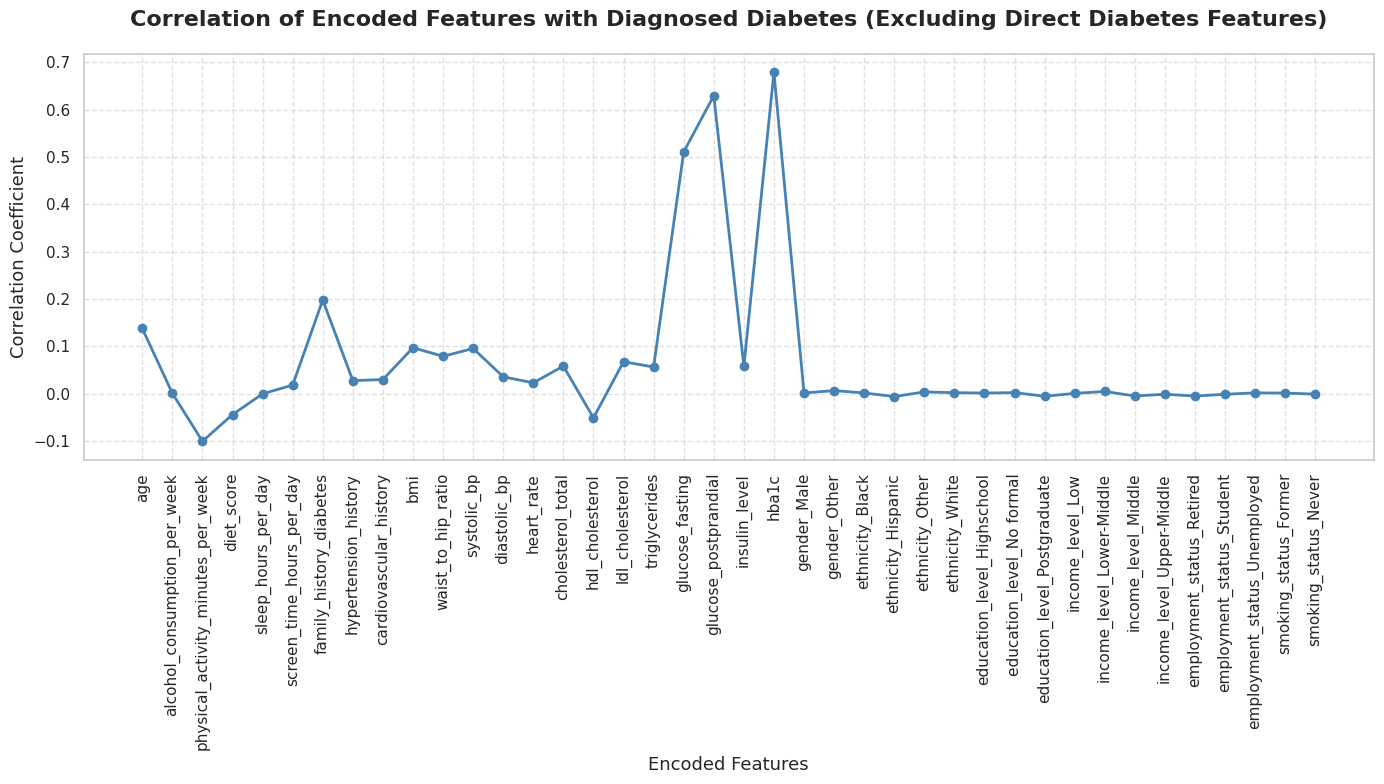

In [41]:
# Encoded all Fertuees Corralation in line graph
# Target and features to exclude (directly related to diabetes)
target = 'diagnosed_diabetes'
exclude_features = [
    'diagnosed_diabetes',
    'diabetes_stage_Type 1',
    'diabetes_stage_Type 2',
    'diabetes_stage_Pre-Diabetes',
    'diabetes_stage_No Diabetes',
    'diabetes_risk_score'
]

# Filter out excluded features
filtered_corr = corr_encoded.drop(index=exclude_features, errors='ignore')

# Create the line graph
plt.figure(figsize=(14, 8))
plt.plot(
    filtered_corr.index,
    filtered_corr[target],
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=6,
    color='steelblue'
)

# Title and labels
plt.title(
    'Correlation of Encoded Features with Diagnosed Diabetes (Excluding Direct Diabetes Features)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('Encoded Features', fontsize=13)
plt.ylabel('Correlation Coefficient', fontsize=13)

# Rotate labels for readability
plt.xticks(rotation=90)

# Add grid and style improvements
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Blood sugar levels and related health measures (HbA1c, glucose, BMI, blood pressure) are the biggest clues that someone may have diabetes.Healthy habits like exercise and good cholesterol levels help lower the risk.Demographic factors (like age, gender, or income) don’t play a big direct role here.